# E008 — Drift, staleness and exposure re-balancing

**Hypotheses:** H9 ([docs/hypotheses.md](../../docs/hypotheses.md))

**Question:** What drifts across the ten days, what does a stale model cost, and can an adaptation layer spread exposure without losing CTR?

**Method:** Daily PSI against the training window, churn statistics, a staleness backtest of models frozen at different days, a causal per-genre hourly recalibration, and a replay of a cohort-exposure penalty with doubly robust CTR estimates.

In [1]:
from charade.analysis.experiment import setup

ctx = setup()
f"mode: {'smoke (fixture, tiny model)' if ctx.smoke else 'full data'}"

'mode: full data'

In [2]:
import matplotlib.pyplot as plt
from IPython.display import Markdown

from charade.analysis import adaptation, drift
from charade.analysis.experiment import ensure_bundle

ensure_bundle(ctx)
tables = drift.run(ctx.settings, ctx.data_dir, ctx.reports / "drift")
tables["Daily mix and churn"]

day,impressions,ctr,first_seen_character_share,top100_jaccard_prev_day,character_hhi,new_creative_share
str,i64,f64,f64,f64,f64,f64
"""2014-10-21""",111065,0.179183,1.0,NaN,0.000656,1.0
"""2014-10-22""",143836,0.166627,0.010846,0.754386,0.000618,0.34433
"""2014-10-23""",104452,0.191638,0.005256,0.652893,0.000602,0.22282
"""2014-10-24""",89378,0.184329,0.005012,0.538462,0.000586,0.132214
"""2014-10-25""",90218,0.192545,0.008402,0.481481,0.000585,0.025749
"""2014-10-26""",103948,0.194972,0.005281,0.538462,0.000583,0.026369
"""2014-10-27""",86788,0.195465,0.003365,0.5625,0.000594,0.133786
"""2014-10-28""",142909,0.165357,0.007081,0.550388,0.000608,0.342407
"""2014-10-29""",104450,0.172705,0.003973,0.680672,0.000629,0.235807


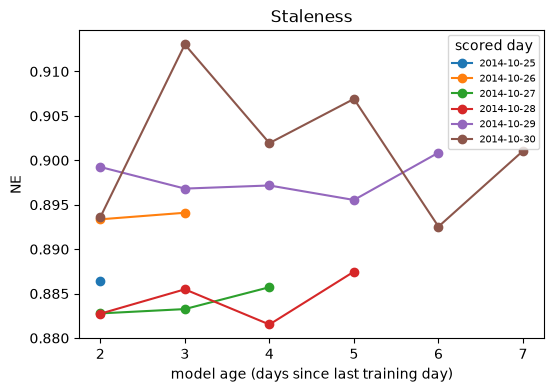

In [3]:
stale = tables[drift.STALE_TITLE]
_, ax = plt.subplots(figsize=(6, 4))
for (day,), part in stale.group_by("scored_day", maintain_order=True):
    ax.plot(part["age_days"], part["ne"], "o-", label=str(day))
ax.set(xlabel="model age (days since last training day)", ylabel="NE", title="Staleness")
ax.legend(title="scored day", fontsize=7)
plt.show()

In [4]:
adaptation.run(ctx.settings, ctx.data_dir, ctx.reports / "drift" / "adaptation.md")
Markdown((ctx.reports / "drift" / "adaptation.md").read_text())

# Adaptation layer (generated by `uv run poe adapt`)

Cohort-exposure penalty vs greedy pCTR (lambda = 0); half-life 2000 cohort impressions; DR with the independent reward model.

Selection rule (pre-registered, validation day only): largest lambda whose 95 % lower bound on the change vs greedy is >= -0.2 pp (non-inferiority). **Chosen lambda = 2.**

## Validation day (selection)

| lambda | dr_ctr | dr_delta_vs_greedy | ci_low | ci_high | cohort_dominance | cohort_hhi | repeat_exposure |
|---|---|---|---|---|---|---|---|
| 0.0000 | 0.1887 | 0.0000 | 0.0000 | 0.0000 | 0.0929 | 0.0367 | 0.1006 |
| 1.0000 | 0.1972 | 0.0085 | 0.0032 | 0.0136 | 0.0653 | 0.0292 | 0.0974 |
| 2.0000 | 0.1968 | 0.0081 | 0.0028 | 0.0128 | 0.0569 | 0.0263 | 0.0953 |
| 4.0000 | 0.1925 | 0.0037 | -0.0035 | 0.0100 | 0.0525 | 0.0236 | 0.0927 |
| 8.0000 | 0.1940 | 0.0052 | -0.0030 | 0.0134 | 0.0487 | 0.0208 | 0.0900 |
| 16.0000 | 0.1853 | -0.0034 | -0.0137 | 0.0068 | 0.0491 | 0.0178 | 0.0861 |

## Test days (confirmation, 111,368 replayed impressions)

| lambda | dr_ctr | dr_delta_vs_greedy | ci_low | ci_high | cohort_dominance | cohort_hhi | repeat_exposure |
|---|---|---|---|---|---|---|---|
| 0.0000 | 0.1893 | 0.0000 | 0.0000 | 0.0000 | 0.0832 | 0.0293 | 0.1026 |
| 1.0000 | 0.1903 | 0.0010 | -0.0033 | 0.0056 | 0.0691 | 0.0243 | 0.0997 |
| 2.0000 | 0.1898 | 0.0006 | -0.0060 | 0.0074 | 0.0629 | 0.0222 | 0.0973 |
| 4.0000 | 0.1881 | -0.0012 | -0.0089 | 0.0070 | 0.0582 | 0.0199 | 0.0943 |
| 8.0000 | 0.1870 | -0.0023 | -0.0085 | 0.0040 | 0.0508 | 0.0170 | 0.0909 |
| 16.0000 | 0.1864 | -0.0029 | -0.0123 | 0.0081 | 0.0438 | 0.0147 | 0.0886 |


## Reading
- The CTR level moves for every genre together; character preferences are stable.
- With equal 3-day training windows, NE does not worsen with model age within a week; the calibration ratio does (about +1.2 % per day). Daily retraining is for calibration and new creatives, not ranking decay.
- lambda is chosen on the validation day by the pre-registered rule; the test days only confirm it.
- The replay uses logged exposure history, so it can show "no CTR loss" but never a fatigue benefit.

## Conclusion
Ads rotate fast (13-37 % new creatives a day) and a frozen model keeps its ranking quality for a week but its calibration drifts (+1.2 % pred/obs per day of age), so retrain daily; online recalibration slightly worsens NE on the validation day; the exposure penalty selected on the validation day by a pre-registered non-inferiority rule (lambda = 2) cuts cohort HHI 24 % on test at +0.06 pp CTR [-0.60, +0.74], which does not confirm non-inferiority at the 0.2 pp margin.

**Decision:** Daily retraining with gated promotion; no online recalibration; exposure penalty at lambda = 2 (chosen on validation) is a candidate for an online A/B test, not shipped: test does not confirm non-inferiority.